# Modeling Criteria EDA

Which findings from the normative-v2 exploration actually became engine thresholds, and were they justified? All thresholds below are imported from `config.MODELING_PARAMS_V2` / `Modeling.dispersion_trend` -- nothing here is re-derived independently of the engine.

In [16]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import statsmodels.api as sm
from scipy.sparse import issparse
from scipy.stats import norm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

_ROOT = Path.cwd().parent
for p in (_ROOT, _ROOT / "Modeling"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
import config
from dispersion_trend import build_trend, load_trend
from model_engine_v2 import _poisson_rqr, _nb_rqr
from viz_style import apply_style

apply_style()

MP2 = config.MODELING_PARAMS_V2
OUT_DIR = Path.cwd() / "Analysis_Results"
FIG_DIR = OUT_DIR / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Engine thresholds in use (config.MODELING_PARAMS_V2):")
for k in ["nz_a_max", "nz_bc_split", "trend_min_nz", "beta_explode_thr"]:
    print(f"  {k} = {MP2[k]}")


Engine thresholds in use (config.MODELING_PARAMS_V2):
  nz_a_max = 20
  nz_bc_split = 60
  trend_min_nz = 30
  beta_explode_thr = 5.0


In [ ]:
def load_hc():
    adata = sc.read_h5ad(config.H5AD_PATH)
    m = ((adata.obs["QC_Passed"] == True) & (adata.obs["Phenotype_Processed"].notna()) &
         (adata.obs["Phenotype_Processed"] != "Unknown") &
         (adata.obs["broad_protocol_category"] != "Exome-based (EB)"))
    a = adata[m]
    is_hc = (a.obs["Phenotype_Processed"].astype(str) == "Healthy Control").values
    is_pc = (a.var["GeneType"] == "protein_coding").values
    X = a.obs[config.BIAS_COLUMNS].values.astype(np.float64)[is_hc]
    Xs = StandardScaler().fit_transform(X)
    Y = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    Y = np.round(Y[is_hc][:, is_pc]).astype(np.float64)
    names = np.array(a.var_names[is_pc].tolist())
    strata = a.obs[MP2["stratify_col"]].astype(object).fillna("NA").astype(str).values[is_hc]
    return Xs, Y, names, strata


def cameron_trivedi(y, mu):
    g = (y - mu) ** 2 - y
    x = mu ** 2
    denom = float((x * x).sum())
    if denom <= 0:
        return np.nan, np.nan
    alpha = float((g * x).sum() / denom)
    resid = g - alpha * x
    dof = len(y) - 1
    if dof <= 0:
        return alpha, np.nan
    se = np.sqrt((resid ** 2).sum() / dof / denom)
    if se <= 0 or not np.isfinite(se):
        return alpha, np.nan
    return alpha, float(norm.sf(alpha / se))


def w1_normal(z):
    v = z[np.isfinite(z)]
    n = len(v)
    if n < 8:
        return np.nan
    ref = norm.ppf(np.linspace(1 / (2 * n), 1 - 1 / (2 * n), n))
    return float(np.mean(np.abs(np.sort(v) - ref)))


: 

In [ ]:
Xs, Y, names, strata = load_hc()
name2idx = {g: i for i, g in enumerate(names)}
print(f"HC={Xs.shape[0]}  protein-coding genes={len(names)}")

## 1. Gating landscape

Route sizes at the engine's actual `nz_a_max` / `nz_bc_split`.

route
C    16880
B     1762
A     1455
Name: count, dtype: int64


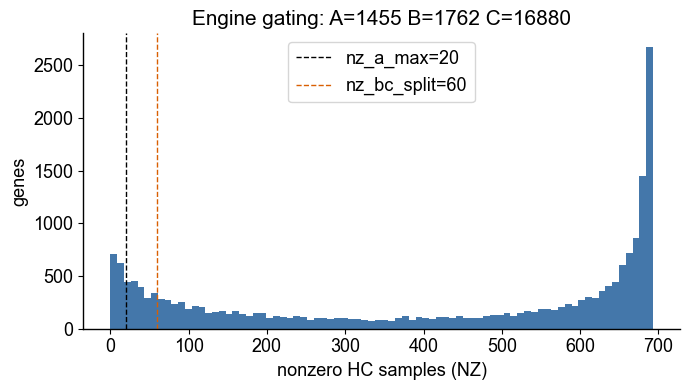

In [ ]:
nz = (Y > 0).sum(0).astype(int)
route = np.where(nz < MP2["nz_a_max"], "A",
                np.where(nz < MP2["nz_bc_split"], "B", "C"))
gating_df = pd.DataFrame({"gene": names, "nz": nz, "route": route})
gating_df.to_csv(OUT_DIR / "gating_landscape.csv", index=False)

route_counts = gating_df["route"].value_counts()
print(route_counts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nz, bins=80, color="#4477aa")
ax.axvline(MP2["nz_a_max"], color="k", ls="--", lw=1, label=f"nz_a_max={MP2['nz_a_max']}")
ax.axvline(MP2["nz_bc_split"], color="#d95f02", ls="--", lw=1, label=f"nz_bc_split={MP2['nz_bc_split']}")
ax.set(xlabel="nonzero HC samples (NZ)", ylabel="genes",
      title=f"Engine gating: A={route_counts.get('A',0)} B={route_counts.get('B',0)} C={route_counts.get('C',0)}")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "gating_landscape.png", dpi=150)
plt.show()


## 2. Route B overdispersion

Cameron-Trivedi NB2 test justifying why Route B cannot be plain Poisson -- the premise for borrowing dispersion from the trend instead of assuming Poisson.

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:527: RuntimeWarning: overflow encountered in exp
  return np.exp(z)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:143: RuntimeWarning: invalid value encountered in multiply
  return 1. / (self.link.deriv(mu)**2 * self.variance(mu))
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:143: RuntimeWarning: divide by zero encountered in divide
  return 1. / (self.link.deriv(mu)**2 * self.variance(mu))
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1328: RuntimeWarning: invalid value encountered in multiply
  wlsendog = (lin_pred + self.family.link.deriv(mu) * (self.endog-mu)


Route B genes tested: 1761
Significantly overdispersed (Cameron-Trivedi p<0.05): 81.1%


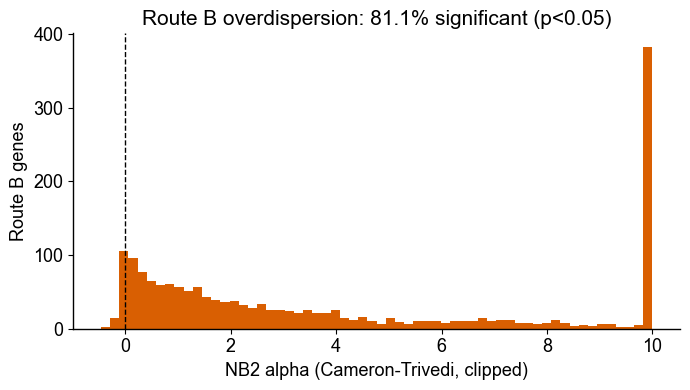

In [ ]:
b_genes = gating_df.loc[gating_df["route"] == "B", "gene"].values
Xc = sm.add_constant(Xs)
rows = []
for g in b_genes:
    y = Y[:, name2idx[g]]
    try:
        res = sm.GLM(y, Xc, family=sm.families.Poisson()).fit()
    except Exception:
        continue
    mu = np.clip(res.mu, 1e-8, None)
    alpha, p = cameron_trivedi(y, mu)
    rows.append({"gene": g, "ct_alpha": alpha, "ct_p": p,
                "pearson_disp": float(res.pearson_chi2 / res.df_resid)})

overdisp_df = pd.DataFrame(rows)
overdisp_df["overdispersed"] = overdisp_df["ct_p"] < 0.05
overdisp_df.to_csv(OUT_DIR / "routeB_overdispersion.csv", index=False)

print(f"Route B genes tested: {len(overdisp_df)}")
print(f"Significantly overdispersed (Cameron-Trivedi p<0.05): {overdisp_df['overdispersed'].mean():.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(overdisp_df["ct_alpha"].clip(-1, 10), bins=60, color="#d95f02")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set(xlabel="NB2 alpha (Cameron-Trivedi, clipped)", ylabel="Route B genes",
      title=f"Route B overdispersion: {overdisp_df['overdispersed'].mean():.1%} significant (p<0.05)")
fig.tight_layout(); fig.savefig(FIG_DIR / "routeB_overdispersion.png", dpi=150)
plt.show()


## 3. Dispersion trend shape: single log-log line vs lowess (used by the engine)

`build_trend`/`load_trend` here are the exact functions `model_engine_v2.py` calls. This section checks whether the engine's lowess choice is actually necessary here, or whether a single log-log line would have been adequate -- not to force a particular answer either way.

In [ ]:
trend = build_trend(Y, min_nz=MP2["trend_min_nz"])  # same call the engine makes
mean_c = Y.mean(0)
var_c = Y.var(0)
with np.errstate(divide="ignore", invalid="ignore"):
    sigma_mom = np.where(mean_c > 0, (var_c - mean_c) / mean_c ** 2, np.nan)
sigma_mom = np.clip(sigma_mom, 0, None)
reliable = (nz >= MP2["trend_min_nz"]) & (mean_c > 0) & np.isfinite(sigma_mom)
mu, sig = mean_c[reliable], sigma_mom[reliable]

pos = sig > 1e-3
lx, ly = np.log(mu[pos]), np.log(sig[pos])
line = sm.OLS(ly, sm.add_constant(lx)).fit()
r2_line = float(line.rsquared)
resid_line = ly - line.predict(sm.add_constant(lx))

logmu = np.asarray(trend["lowess_logmu"])
logsig = np.asarray(trend["lowess_logsigma"])

# Same-basis comparison: interpolate the lowess curve onto the SAME lx points the
# line was fit on, then score both with the same residual-based metrics (R2, RMSE,
# MAE) instead of comparing a parametric R2 to an unscored smoother.
ly_hat_lowess = np.interp(lx, logmu, logsig, left=logsig[0], right=logsig[-1])
resid_lowess = ly - ly_hat_lowess
ss_res_lowess = float((resid_lowess ** 2).sum())
ss_tot = float(((ly - ly.mean()) ** 2).sum())
r2_lowess = 1 - ss_res_lowess / ss_tot
rmse_line = float(np.sqrt((resid_line ** 2).mean()))
rmse_lowess = float(np.sqrt((resid_lowess ** 2).mean()))
mae_line = float(np.abs(resid_line).mean())
mae_lowess = float(np.abs(resid_lowess).mean())

trend_comparison = pd.DataFrame({
    "criterion": ["single log-log line", "lowess on log-log MoM (used by engine)"],
    "r2": [r2_line, r2_lowess],
    "rmse_logsigma": [rmse_line, rmse_lowess],
    "mae_logsigma": [mae_line, mae_lowess],
})
trend_comparison.to_csv(OUT_DIR / "dispersion_trend_fit_comparison.csv", index=False)
print(trend_comparison.to_string(index=False))
print(f"\nGlobal fit: line R2={r2_line:.3f} vs lowess R2={r2_lowess:.3f}. "
     "See 3b for whether either differs systematically by mu range.")

grid = np.geomspace(mu.min(), mu.max(), 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mu, sig, s=3, alpha=0.08, color="#bbbbbb", label="per-gene MoM sigma")
ax.plot(grid, np.exp(line.params[0] + line.params[1] * np.log(grid)), color="#7570b3",
       lw=2, label=f"single log-log line (R2={r2_line:.2f}, RMSE={rmse_line:.2f})")
ax.plot(np.exp(logmu), np.exp(logsig), color="#d95f02", lw=2.5,
       label=f"lowess (R2={r2_lowess:.2f}, RMSE={rmse_lowess:.2f})")
ax.set(xscale="log", yscale="log", xlabel="mu (raw mean)", ylabel="sigma (NB2 dispersion)")
ax.legend(); fig.tight_layout()
fig.savefig(FIG_DIR / "dispersion_trend_fit_comparison.png", dpi=150)
plt.show()


### 3b. Is the line actually worse, or does the global R2/RMSE just hide it?

Global R2/RMSE average over all points, so a line that is biased at the low-mu and high-mu ends but fine in the middle can still score similarly to lowess overall (the middle dominates the point count). Bin by mu quintile and look at **signed** mean residual (bias) and RMSE per bin -- this is the only way to tell whether the line's plateau-mismatch actually matters, or whether a single line is in fact adequate here.

          mu_range    n  bias_line  bias_lowess  rmse_line  rmse_lowess
     [0.053, 0.83] 2263     -0.103        0.338      0.898        0.885
       [0.83, 3.4] 2264      0.389        0.399      0.887        0.896
         [3.4, 15] 2265      0.172        0.149      0.571        0.559
          [15, 40] 2263     -0.107        0.011      0.419        0.402
          [40, 85] 2265     -0.270       -0.084      0.433        0.348
     [85, 1.8e+02] 2264     -0.257       -0.082      0.435        0.361
[1.8e+02, 4.2e+02] 2264     -0.157       -0.078      0.401        0.374
  [4.2e+02, 3e+05] 2265      0.332       -0.040      0.642        0.341


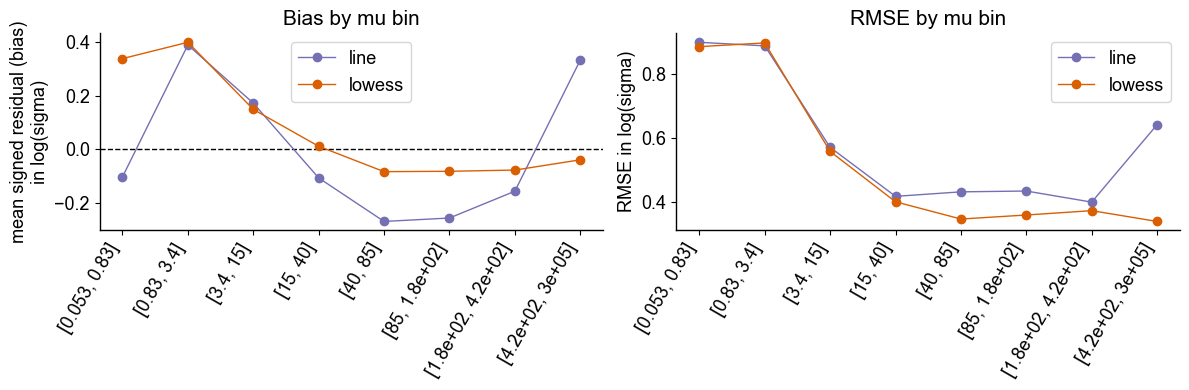

In [ ]:
n_q = 8
q_edges = np.quantile(lx, np.linspace(0, 1, n_q + 1))
q_edges[0] -= 1e-6
qbin = np.clip(np.digitize(lx, q_edges) - 1, 0, n_q - 1)

rows = []
for b in range(n_q):
    m = qbin == b
    if m.sum() < 5:
        continue
    rows.append({
        "mu_range": f"[{np.exp(lx[m].min()):.2g}, {np.exp(lx[m].max()):.2g}]",
        "n": int(m.sum()),
        "bias_line": float(resid_line[m].mean()),
        "bias_lowess": float(resid_lowess[m].mean()),
        "rmse_line": float(np.sqrt((resid_line[m] ** 2).mean())),
        "rmse_lowess": float(np.sqrt((resid_lowess[m] ** 2).mean())),
    })
bin_df = pd.DataFrame(rows)
bin_df.to_csv(OUT_DIR / "dispersion_trend_fit_by_mu_bin.csv", index=False)
print(bin_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(bin_df))
axes[0].axhline(0, color="k", ls="--", lw=1)
axes[0].plot(x, bin_df["bias_line"], "-o", color="#7570b3", label="line")
axes[0].plot(x, bin_df["bias_lowess"], "-o", color="#d95f02", label="lowess")
axes[0].set(ylabel="mean signed residual (bias)\nin log(sigma)", title="Bias by mu bin")
axes[0].legend()
axes[1].plot(x, bin_df["rmse_line"], "-o", color="#7570b3", label="line")
axes[1].plot(x, bin_df["rmse_lowess"], "-o", color="#d95f02", label="lowess")
axes[1].set(ylabel="RMSE in log(sigma)", title="RMSE by mu bin")
axes[1].legend()
for ax in axes:
    ax.set_xticks(list(x)); ax.set_xticklabels(bin_df["mu_range"], rotation=60, ha="right")
fig.tight_layout(); fig.savefig(FIG_DIR / "dispersion_trend_fit_by_mu_bin.png", dpi=150)
plt.show()


## 6. Does the trend-dispersion NB actually work well on Route B genes?

This is the section that matters most: not whether the trend curve fits nicely in the abstract, but whether **fixing dispersion from the trend and fitting only the mean** gives well-calibrated held-out z-scores for the genes the engine actually routes to B (`nz_a_max <= NZ < nz_bc_split`). Same 5-fold stratified CV, same RQR helpers the engine uses, scored against plain Poisson as the mis-specified baseline.

In [ ]:
from scipy.stats import kurtosis, skew


def z_stats(z):
    v = z[np.isfinite(z)]
    if len(v) < 8:
        return dict(w1=np.nan, mean_z=np.nan, std_z=np.nan, skew_z=np.nan, kurt_z=np.nan, n_valid=len(v))
    return dict(w1=w1_normal(v), mean_z=float(v.mean()), std_z=float(v.std()),
               skew_z=float(skew(v)), kurt_z=float(kurtosis(v)), n_valid=len(v))


b_idx = np.array([name2idx[g] for g in b_genes])
rows = []
for j in b_idx:
    y = Y[:, j]
    zp, zn = np.full(len(y), np.nan), np.full(len(y), np.nan)
    for fi, (tr, te) in enumerate(folds):
        alpha_g = alpha_fn(float(y[tr].mean()))
        try:
            pois = sm.GLM(y[tr], Xc[tr], family=sm.families.Poisson()).fit()
            zp[te] = _poisson_rqr(y[te], np.clip(pois.predict(Xc[te]), 1e-8, 1e8), 42 + fi)
        except Exception:
            pass
        try:
            nbf = sm.GLM(y[tr], Xc[tr], family=sm.families.NegativeBinomial(alpha=alpha_g)).fit()
            zn[te] = _nb_rqr(y[te], np.clip(nbf.predict(Xc[te]), 1e-8, 1e8), alpha_g, 42 + fi)
        except Exception:
            pass
    row = {"gene": names[j], "nz": int(nz[j])}
    for tag, z in [("pois", zp), ("trend_nb", zn)]:
        for k, v in z_stats(z).items():
            row[f"{tag}_{k}"] = v
    rows.append(row)

routeB_cv = pd.DataFrame(rows)
routeB_cv.to_csv(OUT_DIR / "routeB_calibration.csv", index=False)

print(f"Route B genes evaluated: {len(routeB_cv)}\n")
print("Median calibration (held-out, 5-fold):")
print(routeB_cv[["pois_w1", "trend_nb_w1", "pois_std_z", "trend_nb_std_z",
                "pois_kurt_z", "trend_nb_kurt_z"]].median().to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(routeB_cv["pois_w1"].clip(0, 1), bins=40, alpha=0.6, color="#7570b3", label="Poisson")
axes[0].hist(routeB_cv["trend_nb_w1"].clip(0, 1), bins=40, alpha=0.6, color="#d95f02", label="trend-NB")
axes[0].set(xlabel="W1 to N(0,1)", ylabel="Route B genes", title="Calibration (W1)")
axes[0].legend()
axes[1].hist(routeB_cv["pois_std_z"].clip(0, 3), bins=40, alpha=0.6, color="#7570b3", label="Poisson")
axes[1].hist(routeB_cv["trend_nb_std_z"].clip(0, 3), bins=40, alpha=0.6, color="#d95f02", label="trend-NB")
axes[1].axvline(1, color="k", ls="--", lw=1)
axes[1].set(xlabel="std(z)", title="Spread of held-out z")
axes[1].legend()
axes[2].hist(routeB_cv["pois_kurt_z"].clip(-2, 15), bins=40, alpha=0.6, color="#7570b3", label="Poisson")
axes[2].hist(routeB_cv["trend_nb_kurt_z"].clip(-2, 15), bins=40, alpha=0.6, color="#d95f02", label="trend-NB")
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].set(xlabel="excess kurtosis of z", title="Tail behavior")
axes[2].legend()
fig.suptitle(f"Route B ({len(routeB_cv)} genes, NZ in [{MP2['nz_a_max']},{MP2['nz_bc_split']})): "
            "trend-dispersion NB vs mis-specified Poisson")
fig.tight_layout(); fig.savefig(FIG_DIR / "routeB_calibration.png", dpi=150)
plt.show()
